<a href="https://colab.research.google.com/github/Zackkee/TAM400-Projekt/blob/main/TAM400_Projekt_Zakaria_Leon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

filsökväg = 'https://raw.githubusercontent.com/Zackkee/TAM400-Projekt/refs/heads/main/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df = pd.read_csv(filsökväg)

In [2]:
display(df.head())
df.info()
print(df['Diabetes_binary'].value_counts())

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

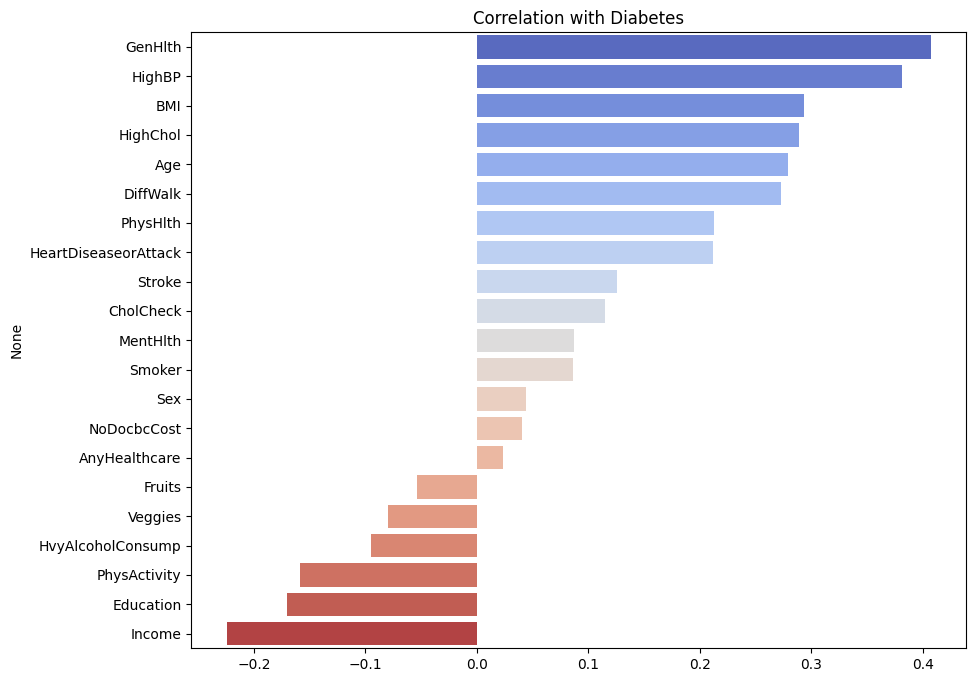

In [3]:
#Stapeldiagram
plt.figure(figsize=(10, 8))
korrelation = df.corr()['Diabetes_binary'].sort_values(ascending=False).drop('Diabetes_binary')
sns.barplot(x=korrelation.values, y=korrelation.index, hue=korrelation.index, palette='coolwarm', legend=False)
plt.title("Correlation with Diabetes")
plt.show()

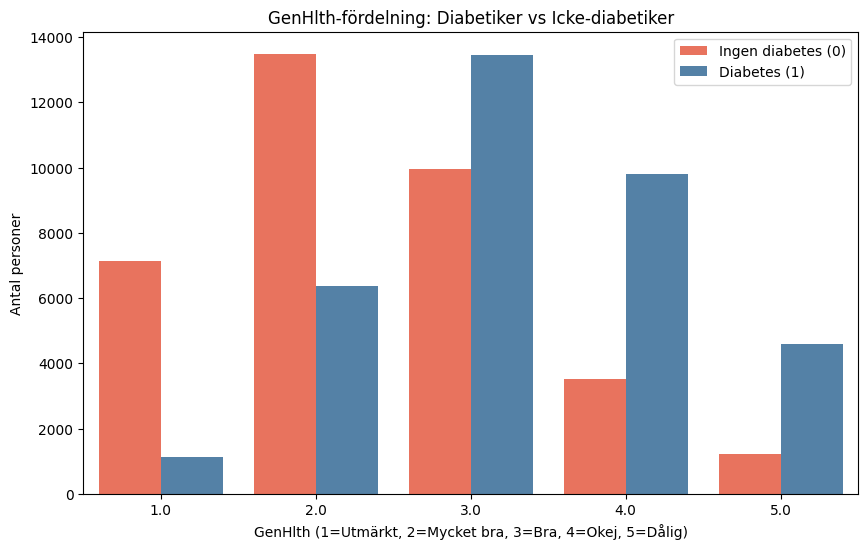

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='GenHlth', hue='Diabetes_binary',
              palette={0: 'tomato', 1: 'steelblue'})
plt.title('GenHlth-fördelning: Diabetiker vs Icke-diabetiker')
plt.xlabel('GenHlth (1=Utmärkt, 2=Mycket bra, 3=Bra, 4=Okej, 5=Dålig)')
plt.ylabel('Antal personer')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'])
plt.show()

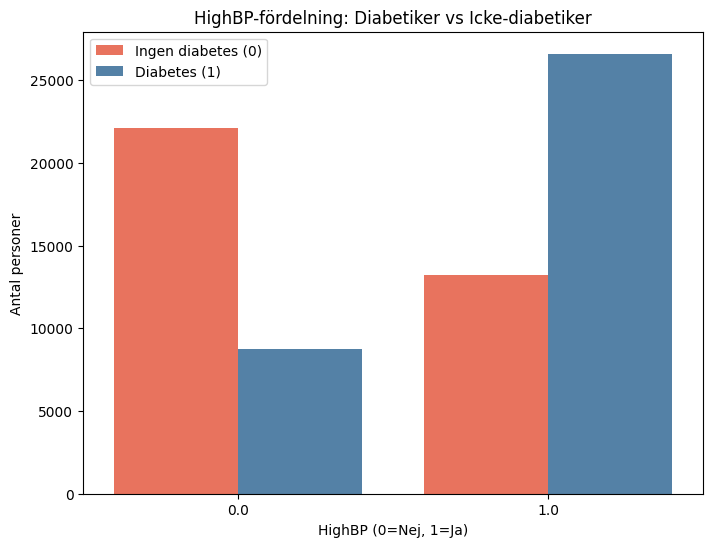

In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='HighBP', hue='Diabetes_binary',
              palette={0: 'tomato', 1: 'steelblue'})
plt.title('HighBP-fördelning: Diabetiker vs Icke-diabetiker')
plt.xlabel('HighBP (0=Nej, 1=Ja)')
plt.ylabel('Antal personer')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'])
plt.show()

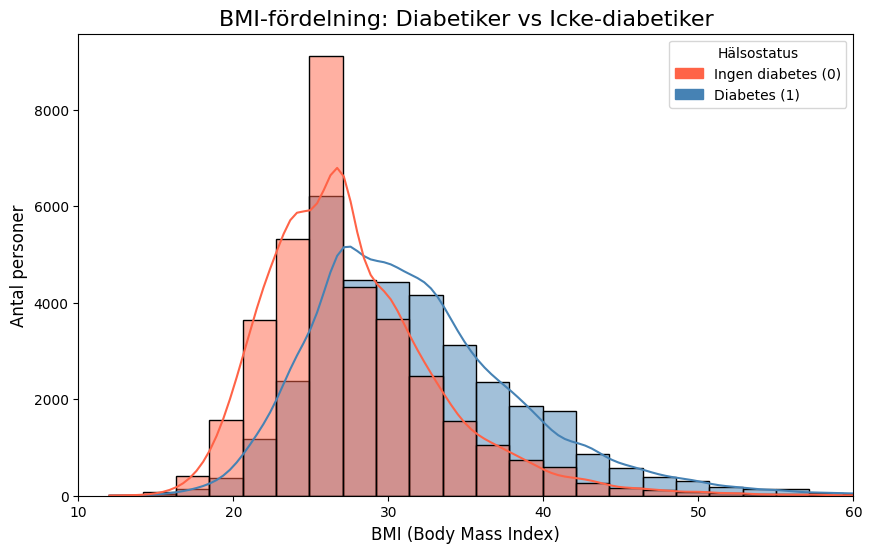

In [6]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="BMI",
    hue="Diabetes_binary",
    bins=40,
    kde=True,
    palette={0: 'tomato', 1: 'steelblue'}
)
plt.title("BMI-fördelning: Diabetiker vs Icke-diabetiker", fontsize=16)
plt.xlabel("BMI (Body Mass Index)", fontsize=12)
plt.ylabel("Antal personer", fontsize=12)

legend_patches = [
    mpatches.Patch(color='tomato', label='Ingen diabetes (0)'),
    mpatches.Patch(color='steelblue', label='Diabetes (1)')
]
plt.legend(handles=legend_patches, title="Hälsostatus")

plt.xlim(10, 60)
plt.show()

# Data Preprocessing(Scaling)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Välj bara de fem features ni vill ha
X = df[['GenHlth', 'HighBP', 'BMI', 'HighChol', 'Age']]
y = df['Diabetes_binary']

# 2. Train/test split med stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling (behövs för Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Logistic Regression — använder SKALAD data
#logreg = LogisticRegression(max_iter=1000)
#logreg.fit(X_train_scaled, y_train)
#y_pred_lr = logreg.predict(X_test_scaled)

#print("=== Logistic Regression ===")
#print("Accuracy:", accuracy_score(y_test, y_pred_lr))
#print(classification_report(y_test, y_pred_lr))

## 5. Decision Tree — använder OSKALAD data (läsbara splits)
#tree = DecisionTreeClassifier(random_state=42)
#tree.fit(X_train, y_train)
#y_pred_dt = tree.predict(X_test)

#print("=== Decision Tree ===")
#print("Accuracy:", accuracy_score(y_test, y_pred_dt))
#print(classification_report(y_test, y_pred_dt))

# Logistic Regression

In [8]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression # <-- Viktigt att importera den

# Skapa modellen (Denna rad är tillagd!)
lr_model = LogisticRegression(max_iter=100)

# Gör förutsägelser med 5-fold cross validation på träningsdatan
y_pred_cv = cross_val_predict(lr_model, X_train_scaled, y_train, cv=5)

# Utvärdera cross-validation-modellen
print("Logistic Regression - Cross Validation Resultat:")
print("Accuracy:", accuracy_score(y_train, y_pred_cv))
print("\nClassification Report:")
print(classification_report(y_train, y_pred_cv))
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pred_cv))

Logistic Regression - Cross Validation Resultat:
Accuracy: 0.7433381076158647

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.72      0.74     28276
         1.0       0.73      0.77      0.75     28277

    accuracy                           0.74     56553
   macro avg       0.74      0.74      0.74     56553
weighted avg       0.74      0.74      0.74     56553


Confusion Matrix:
[[20367  7909]
 [ 6606 21671]]


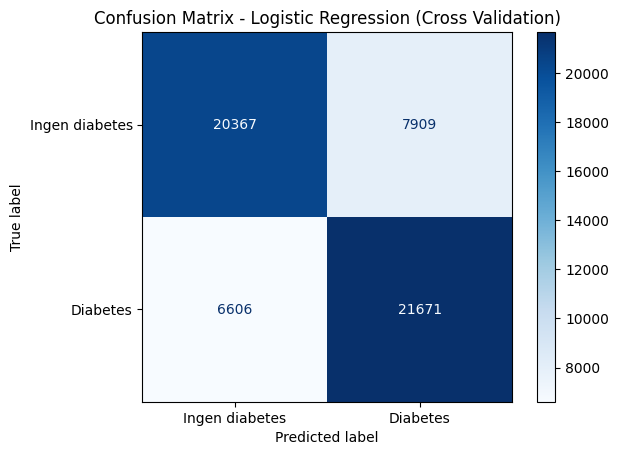

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix graf för Cross Validation
cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ingen diabetes', 'Diabetes'])

# Här lägger vi till values_format='d' för att stänga av e+04-formatet!
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Logistic Regression (Cross Validation)')
plt.show()

# Decision Trees  

Decision Tree - Cross Validation Resultat:
Accuracy: 0.7388997931144237

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.70      0.73     28276
         1.0       0.72      0.78      0.75     28277

    accuracy                           0.74     56553
   macro avg       0.74      0.74      0.74     56553
weighted avg       0.74      0.74      0.74     56553


Confusion Matrix:
[[19702  8574]
 [ 6192 22085]]


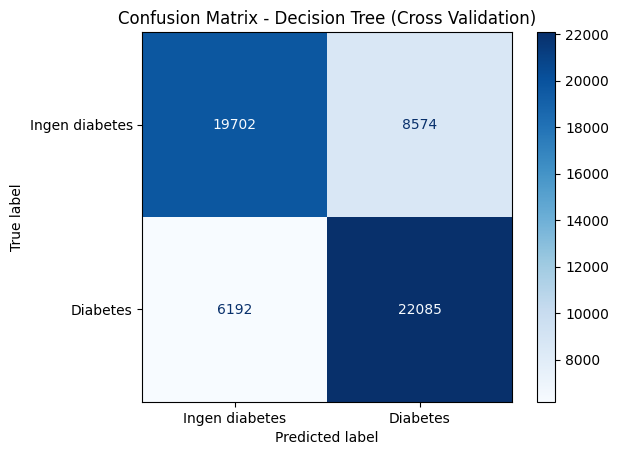

In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Skapa och träna modellen (vi kör på oskalad träningsdata som du planerade)
dt_model = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Gör förutsägelser med 5-fold cross validation
y_pred_dt_cv = cross_val_predict(dt_model, X_train, y_train, cv=5)

# 3. Skriv ut resultat (exakt som din bild)
print("Decision Tree - Cross Validation Resultat:")
print("Accuracy:", accuracy_score(y_train, y_pred_dt_cv))
print("\nClassification Report:")
print(classification_report(y_train, y_pred_dt_cv))
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pred_dt_cv))

# 4. Skapa Confusion Matrix-grafen med läsbara heltal
cm_dt = confusion_matrix(y_train, y_pred_dt_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Ingen diabetes', 'Diabetes'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Decision Tree (Cross Validation)')
plt.show()